# Game Length Analysis

This notebook analyzes the correlation between game duration and outcomes using a dataset of 20,058 chess games from Lichess.org.

**Objectives**
- Analyze move count distribution by game result (win/loss/draw)
- Identify short game outcome patterns and victory types
- Examine long game characteristics and draw probability
- Determine decisive vs non-decisive game length thresholds

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression

## 1. Data Preparation
Loading the chess games dataset and preparing relevant features for game length analysis.

In [47]:
df = pd.read_csv('../data/games.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## 2. Feature Engineering
Creating game length categories and extracting relevant features for analysis.

In [48]:
# Keep relevant columns
columns_to_keep = [
    'id',
    'winner',
    'victory_status',
    'turns',
    'white_rating',
    'black_rating',
    'opening_name',
    'opening_eco'
]

length_df = df[columns_to_keep].copy()

# Calculate rating difference
length_df['rating_diff'] = abs(length_df['white_rating'] - length_df['black_rating'])

# Categorize game length
def categorize_game_length(turns):
    """Categorize games by number of turns"""
    if turns <= 20:
        return 'Short (≤20)'
    elif turns <= 40:
        return 'Medium (21-40)'
    elif turns <= 60:
        return 'Long (41-60)'
    else:
        return 'Very Long (60+)'

length_df['game_length_category'] = length_df['turns'].apply(categorize_game_length)

# Create binary outcome (decisive vs draw)
length_df['is_draw'] = (length_df['winner'] == 'draw').astype(int)

length_df.info()
length_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    20058 non-null  str  
 1   winner                20058 non-null  str  
 2   victory_status        20058 non-null  str  
 3   turns                 20058 non-null  int64
 4   white_rating          20058 non-null  int64
 5   black_rating          20058 non-null  int64
 6   opening_name          20058 non-null  str  
 7   opening_eco           20058 non-null  str  
 8   rating_diff           20058 non-null  int64
 9   game_length_category  20058 non-null  str  
 10  is_draw               20058 non-null  int64
dtypes: int64(5), str(6)
memory usage: 1.7 MB


,id,winner,victory_status,turns,white_rating,black_rating,opening_name,opening_eco,rating_diff,game_length_category,is_draw
0,TZJHLljE,white,outoftime,13,1500,1191,Slav Defense: Exchange Variation,D10,309,Short (≤20),0
1,l1NXvwaE,black,resign,16,1322,1261,Nimzowitsch Defense: Kennedy Variation,B00,61,Short (≤20),0
2,mIICvQHh,white,mate,61,1496,1500,King's Pawn Game: Leonardis Variation,C20,4,Very Long (60+),0
3,kWKvrqYL,white,mate,61,1439,1454,Queen's Pawn Game: Zukertort Variation,D02,15,Very Long (60+),0
4,9tXo1AUZ,white,mate,95,1523,1469,Philidor Defense,C41,54,Very Long (60+),0


## 3. Descriptive Statistics
Basic statistics on game length by outcome.

In [49]:
# Calculate descriptive statistics by outcome
stats_by_outcome = length_df.groupby('winner')['turns'].describe()

# Rename 'count' to 'games'
stats_by_outcome = stats_by_outcome.rename(columns={'count': 'games'})

print("="*70)
print("GAME LENGTH STATISTICS BY OUTCOME")
print("="*70)
print(stats_by_outcome)

# Overall statistics
print(f"\n{'='*70}")
print("OVERALL GAME LENGTH STATISTICS")
print("="*70)
print(f"Mean game length: {length_df['turns'].mean():.2f} turns")
print(f"Median game length: {length_df['turns'].median():.0f} turns")
print(f"Std deviation: {length_df['turns'].std():.2f} turns")
print(f"Min: {length_df['turns'].min():.0f} turns")
print(f"Max: {length_df['turns'].max():.0f} turns")

GAME LENGTH STATISTICS BY OUTCOME
          games       mean        std  min   25%   50%     75%    max
winner                                                               
black    9107.0  60.724388  32.369867  1.0  38.0  56.0   78.00  222.0
draw      950.0  86.157895  45.897861  2.0  50.0  89.0  116.75  259.0
white   10001.0  57.790221  32.193353  1.0  35.0  53.0   75.00  349.0

OVERALL GAME LENGTH STATISTICS
Mean game length: 60.47 turns
Median game length: 55 turns
Std deviation: 33.57 turns
Min: 1 turns
Max: 349 turns


## 4. Game Length Distribution Analysis
Visualizing how game length varies by outcome.

/tmp/ipykernel_7336/395566150.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


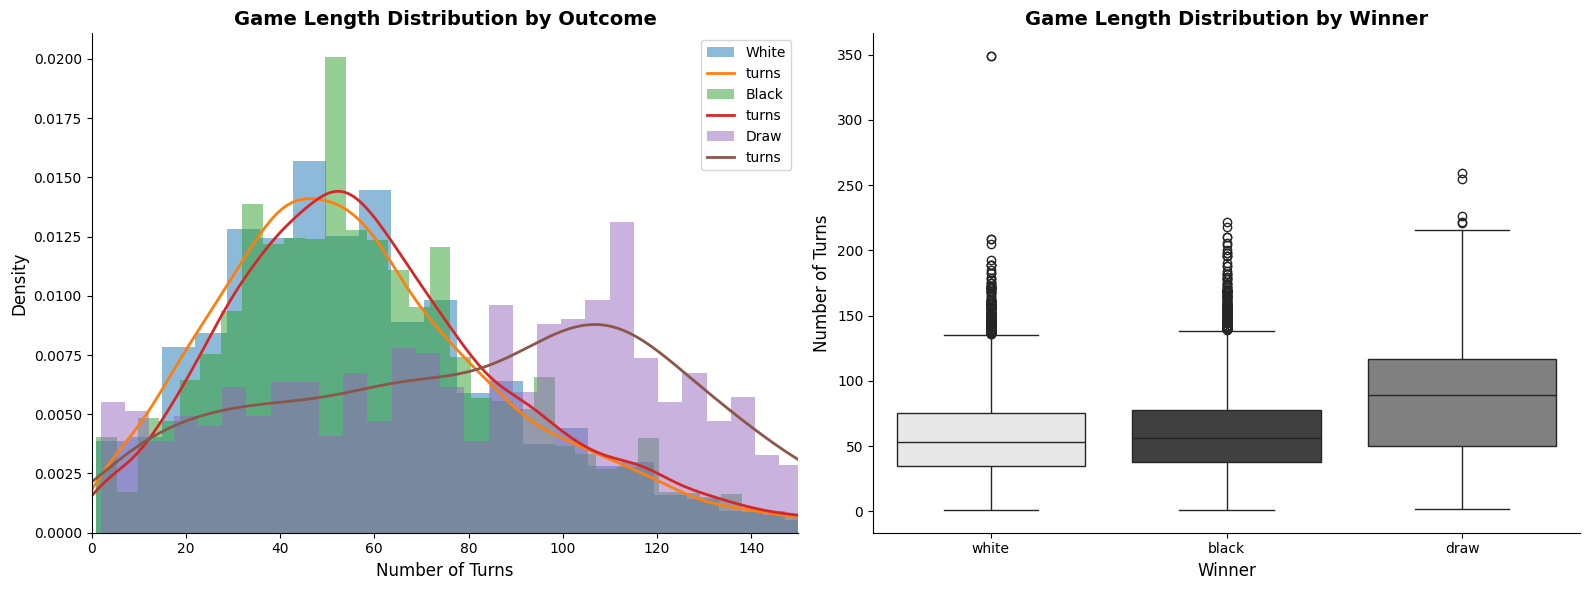

In [ ]:
# Create simplified distribution visualizations (reduced from 4 to 2 panels)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Histogram with KDE by outcome
ax1 = axes[0]
for outcome in ['white', 'black', 'draw']:
    data = length_df[length_df['winner'] == outcome]['turns']
    ax1.hist(data, bins=50, alpha=0.5, label=outcome.capitalize(), density=True)
    data.plot.kde(ax=ax1, linewidth=2)

ax1.set_xlabel('Number of Turns', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Game Length Distribution by Outcome', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_xlim(0, 150)
sns.despine(ax=ax1)

# Panel 2: Box plot by outcome
ax2 = axes[1]
sns.boxplot(
    data=length_df,
    x='winner',
    y='turns',
    hue='winner',
    palette={'white': '#E8E8E8', 'black': '#404040', 'draw': '#808080'},
    legend=False,
    ax=ax2
)
ax2.set_xlabel('Winner', fontsize=12)
ax2.set_ylabel('Number of Turns', fontsize=12)
ax2.set_title('Game Length Distribution by Winner', fontsize=14, fontweight='bold')
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('../images/02_game_length_analysis/game_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Statistical Significance Testing
Testing whether game length differences between outcomes are statistically significant.

In [51]:
# Kruskal-Wallis test (non-parametric alternative to ANOVA)
white_turns = length_df[length_df['winner'] == 'white']['turns']
black_turns = length_df[length_df['winner'] == 'black']['turns']
draw_turns = length_df[length_df['winner'] == 'draw']['turns']

h_stat, p_value = stats.kruskal(white_turns, black_turns, draw_turns)

print("="*70)
print("KRUSKAL-WALLIS TEST (Game Length by Outcome)")
print("="*70)
print(f"H-statistic: {h_stat:.2f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.001:
    print(f"Result: HIGHLY SIGNIFICANT (p < 0.001)")
elif p_value < 0.05:
    print(f"Result: SIGNIFICANT (p < 0.05)")
else:
    print(f"Result: NOT SIGNIFICANT (p >= 0.05)")

# Calculate effect size (eta-squared)
n = len(length_df)
eta_squared = (h_stat - 2) / (n - 3)

print(f"\nEffect size (eta-squared): {eta_squared:.4f}")
print(f"Interpretation: ", end="")
if eta_squared < 0.01:
    print("Negligible effect")
elif eta_squared < 0.06:
    print("Small effect")
elif eta_squared < 0.14:
    print("Medium effect")
else:
    print("Large effect")

# Pairwise comparisons with Mann-Whitney U test
print(f"\n{'='*70}")
print("PAIRWISE COMPARISONS (Mann-Whitney U Test)")
print("="*70)

comparisons = [
    ('White wins', 'Black wins', white_turns, black_turns),
    ('White wins', 'Draws', white_turns, draw_turns),
    ('Black wins', 'Draws', black_turns, draw_turns)
]

for name1, name2, data1, data2 in comparisons:
    u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    median_diff = data1.median() - data2.median()
    print(f"\n{name1} vs {name2}:")
    print(f"  Median difference: {median_diff:.1f} turns")
    print(f"  U-statistic: {u_stat:.0f}")
    print(f"  p-value: {p_val:.6f}")
    if p_val < 0.001:
        print(f"  Result: HIGHLY SIGNIFICANT")
    elif p_val < 0.05:
        print(f"  Result: SIGNIFICANT")
    else:
        print(f"  Result: NOT SIGNIFICANT")

KRUSKAL-WALLIS TEST (Game Length by Outcome)
H-statistic: 397.68
p-value: 0.000000
Result: HIGHLY SIGNIFICANT (p < 0.001)

Effect size (eta-squared): 0.0197
Interpretation: Small effect

PAIRWISE COMPARISONS (Mann-Whitney U Test)

White wins vs Black wins:
  Median difference: -3.0 turns
  U-statistic: 42972690
  p-value: 0.000000
  Result: HIGHLY SIGNIFICANT

White wins vs Draws:
  Median difference: -36.0 turns
  U-statistic: 2954248
  p-value: 0.000000
  Result: HIGHLY SIGNIFICANT

Black wins vs Draws:
  Median difference: -33.0 turns
  U-statistic: 2845774
  p-value: 0.000000
  Result: HIGHLY SIGNIFICANT


## 6. Draw Probability by Game Length
Analyzing how draw probability changes with game duration.

In [52]:
# Calculate draw rate by game length bins
bins = range(0, int(length_df['turns'].max()) + 10, 10)
length_df['turn_bin'] = pd.cut(length_df['turns'], bins=bins)

draw_rate_by_bin = length_df.groupby('turn_bin')['is_draw'].agg(['mean', 'count', 'sum'])
draw_rate_by_bin['percentage'] = draw_rate_by_bin['mean'] * 100

# Calculate Wilson confidence intervals
def wilson_ci(successes, total, confidence=0.95):
    """Calculate Wilson score confidence interval for a proportion"""
    if total == 0:
        return 0, 0
    z = norm.ppf((1 + confidence) / 2)
    p_hat = successes / total
    denominator = 1 + z**2 / total
    center = (p_hat + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * total)) / total) / denominator
    return (center - margin) * 100, (center + margin) * 100

ci_lower = []
ci_upper = []
for idx, row in draw_rate_by_bin.iterrows():
    lower, upper = wilson_ci(row['sum'], row['count'])
    ci_lower.append(lower)
    ci_upper.append(upper)

draw_rate_by_bin['ci_lower'] = ci_lower
draw_rate_by_bin['ci_upper'] = ci_upper

# Get bin midpoints for plotting
bin_midpoints = [interval.mid for interval in draw_rate_by_bin.index]

print("="*70)
print("DRAW PROBABILITY BY GAME LENGTH")
print("="*70)
print("\nDraw rate by turn bins:")
print(draw_rate_by_bin[['count', 'sum', 'percentage']].head(15))

DRAW PROBABILITY BY GAME LENGTH

Draw rate by turn bins:
            count  sum  percentage
turn_bin                          
(0, 10]       681   40    5.873715
(10, 20]     1114   44    3.949731
(20, 30]     1771   51    2.879729
(30, 40]     2377   49    2.061422
(40, 50]     2708   56    2.067947
(50, 60]     2754   53    1.924473
(60, 70]     2227   68    3.053435
(70, 80]     1684   58    3.444181
(80, 90]     1249   66    5.284227
(90, 100]     957   80    8.359457
(100, 110]    754   87   11.538462
(110, 120]    644   92   14.285714
(120, 130]    392   60   15.306122
(130, 140]    269   51   18.959108
(140, 150]    188   29   15.425532


In [53]:
# Logistic regression to model draw probability
X = length_df[['turns']].values
y = length_df['is_draw'].values

# Fit logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)

# Generate predictions
X_pred = np.arange(0, 150, 1).reshape(-1, 1)
y_pred_prob = log_reg.predict_proba(X_pred)[:, 1] * 100

# Find threshold where draw probability exceeds 50%
threshold_idx = np.where(y_pred_prob >= 50)[0]
if len(threshold_idx) > 0:
    threshold_turns = X_pred[threshold_idx[0]][0]
else:
    threshold_turns = None

print(f"\n{'='*70}")
print("LOGISTIC REGRESSION MODEL")
print("="*70)
print(f"Coefficient (turns): {log_reg.coef_[0][0]:.6f}")
print(f"Intercept: {log_reg.intercept_[0]:.6f}")
if threshold_turns:
    print(f"\nThreshold where draw probability reaches 50%: {threshold_turns:.0f} turns")
else:
    print(f"\nDraw probability does not reach 50% within observed range")

# Calculate draw probability at key milestones
milestones = [20, 40, 60, 80, 100]
print(f"\nDraw probability at key milestones:")
for milestone in milestones:
    prob = log_reg.predict_proba([[milestone]])[0][1] * 100
    print(f"  {milestone} turns: {prob:.2f}%")


LOGISTIC REGRESSION MODEL
Coefficient (turns): 0.019249
Intercept: -4.375875

Draw probability does not reach 50% within observed range

Draw probability at key milestones:
  20 turns: 1.81%
  40 turns: 2.64%
  60 turns: 3.84%
  80 turns: 5.54%
  100 turns: 7.94%


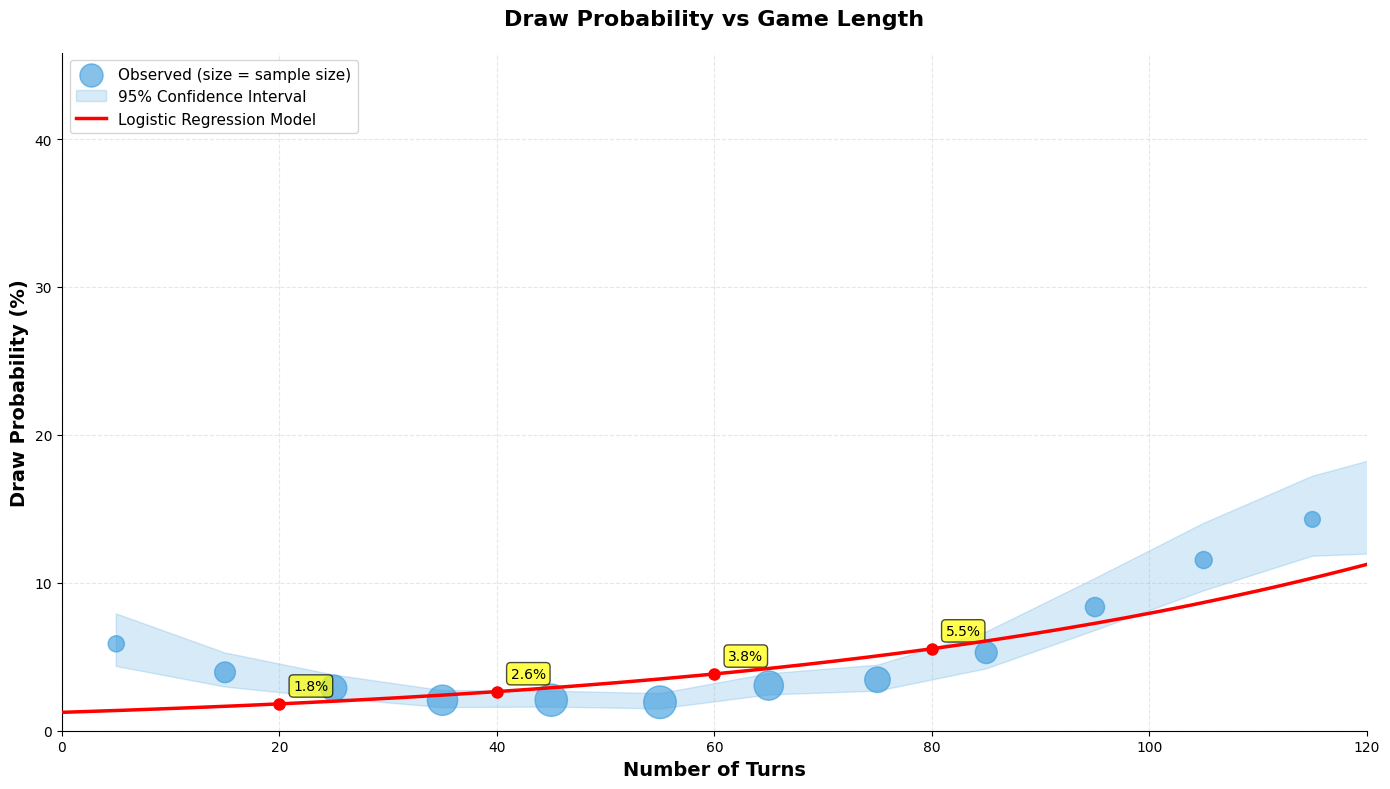

In [54]:
# Visualize draw probability curve
fig, ax = plt.subplots(figsize=(14, 8))

# Plot observed data with confidence intervals
valid_bins = draw_rate_by_bin[draw_rate_by_bin['count'] >= 10]
valid_midpoints = [interval.mid for interval in valid_bins.index]

ax.scatter(valid_midpoints, valid_bins['percentage'], 
          s=valid_bins['count']/5, alpha=0.6, color='#3498db', 
          label='Observed (size = sample size)', zorder=3)

ax.fill_between(valid_midpoints, 
               valid_bins['ci_lower'], 
               valid_bins['ci_upper'],
               alpha=0.2, color='#3498db', label='95% Confidence Interval')

# Plot logistic regression curve
ax.plot(X_pred, y_pred_prob, 'r-', linewidth=2.5, 
       label='Logistic Regression Model', zorder=4)

# Add threshold line if exists
if threshold_turns:
    ax.axvline(threshold_turns, color='green', linestyle='--', linewidth=2,
              label=f'50% Draw Threshold ({threshold_turns:.0f} turns)', zorder=2)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)

# Add milestone annotations
for milestone in [20, 40, 60, 80]:
    prob = log_reg.predict_proba([[milestone]])[0][1] * 100
    ax.plot(milestone, prob, 'ro', markersize=8, zorder=5)
    ax.annotate(f'{prob:.1f}%', 
               xy=(milestone, prob), 
               xytext=(10, 10), 
               textcoords='offset points',
               fontsize=10,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Number of Turns', fontsize=14, fontweight='bold')
ax.set_ylabel('Draw Probability (%)', fontsize=14, fontweight='bold')
ax.set_title('Draw Probability vs Game Length', fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0, 120)
ax.set_ylim(0, max(valid_bins['percentage'].max(), y_pred_prob.max()) * 1.1)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine()

plt.tight_layout()
plt.savefig('../images/02_game_length_analysis/draw_probability_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Game Length by Category Analysis
Comparing outcomes across different game length categories.

In [55]:
# Analyze outcomes by game length category
category_analysis = length_df.groupby(['game_length_category', 'winner']).size().unstack(fill_value=0)
category_pct = length_df.groupby(['game_length_category', 'winner']).size().unstack(fill_value=0)
category_pct = category_pct.div(category_pct.sum(axis=1), axis=0) * 100

category_order = ['Short (≤20)', 'Medium (21-40)', 'Long (41-60)', 'Very Long (60+)']
category_pct = category_pct.reindex(category_order)

print("="*70)
print("OUTCOME DISTRIBUTION BY GAME LENGTH CATEGORY")
print("="*70)
print("\nPercentage distribution:")
print(category_pct.round(2))

print(f"\n{'='*70}")
print("KEY INSIGHTS BY CATEGORY")
print("="*70)
for category in category_order:
    if category in category_pct.index:
        row = category_pct.loc[category]
        total_games = category_analysis.loc[category].sum()
        print(f"\n{category}: {total_games:,} games")
        print(f"  White wins: {row['white']:.2f}%")
        print(f"  Black wins: {row['black']:.2f}%")
        if 'draw' in row.index:
            print(f"  Draws: {row['draw']:.2f}%")
        decisive_rate = 100 - (row['draw'] if 'draw' in row.index else 0)
        print(f"  Decisive rate: {decisive_rate:.2f}%")

OUTCOME DISTRIBUTION BY GAME LENGTH CATEGORY

Percentage distribution:
winner                black  draw  white
game_length_category                    
Short (≤20)           41.17  4.68  54.15
Medium (21-40)        45.03  2.41  52.56
Long (41-60)          46.92  2.00  51.08
Very Long (60+)       45.50  7.59  46.91

KEY INSIGHTS BY CATEGORY

Short (≤20): 1,795 games
  White wins: 54.15%
  Black wins: 41.17%
  Draws: 4.68%
  Decisive rate: 95.32%

Medium (21-40): 4,148 games
  White wins: 52.56%
  Black wins: 45.03%
  Draws: 2.41%
  Decisive rate: 97.59%

Long (41-60): 5,462 games
  White wins: 51.08%
  Black wins: 46.92%
  Draws: 2.00%
  Decisive rate: 98.00%

Very Long (60+): 8,653 games
  White wins: 46.91%
  Black wins: 45.50%
  Draws: 7.59%
  Decisive rate: 92.41%


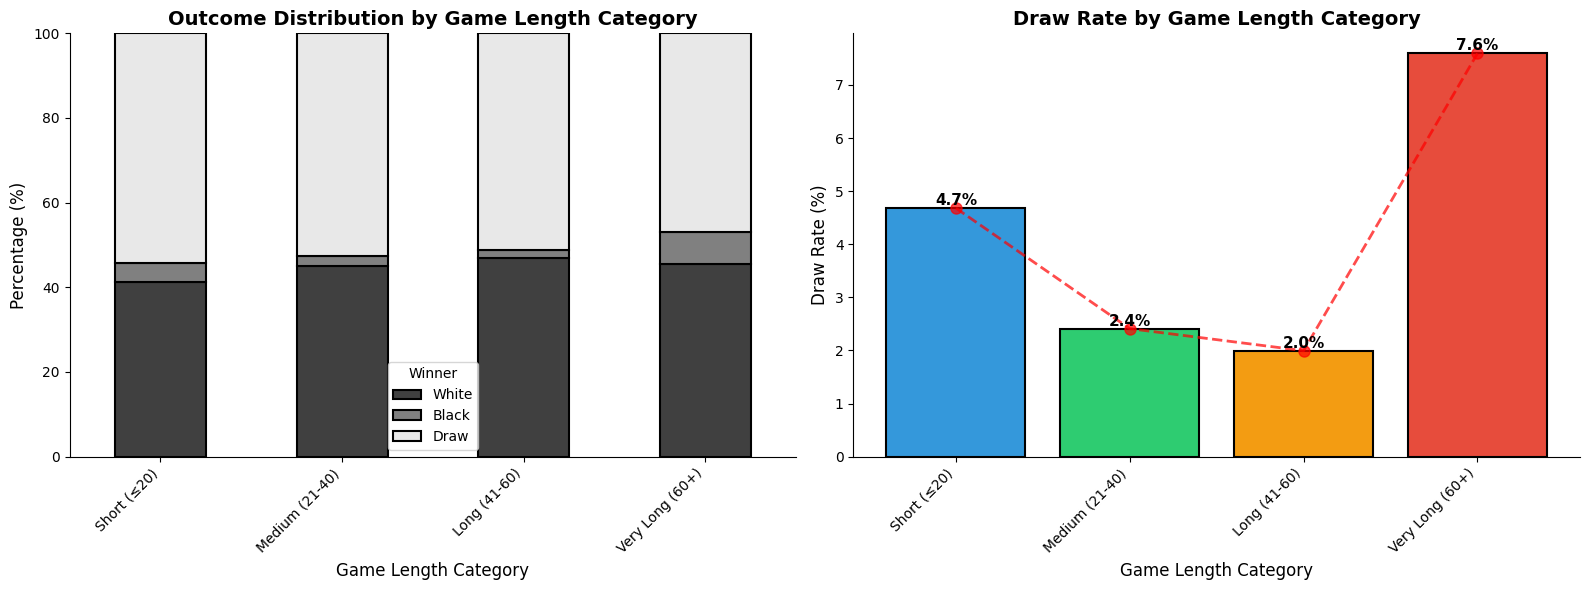

In [ ]:
# Visualize outcome distribution by category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Stacked bar chart
category_pct.plot(kind='bar', stacked=True, ax=ax1,
                 color={'white': '#E8E8E8', 'black': '#404040', 'draw': '#808080'},
                 edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Game Length Category', fontsize=12)
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_title('Outcome Distribution by Game Length Category', fontsize=14, fontweight='bold')
ax1.legend(title='Winner', labels=['Black', 'Draw', 'White'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim(0, 100)
sns.despine(ax=ax1)

# Panel 2: Draw rate progression
draw_rates = []
categories = []
for category in category_order:
    if category in category_pct.index and 'draw' in category_pct.columns:
        draw_rates.append(category_pct.loc[category, 'draw'])
        categories.append(category)

bars = ax2.bar(range(len(categories)), draw_rates, 
              color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'],
              edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(categories)))
ax2.set_xticklabels(categories, rotation=45, ha='right')
ax2.set_xlabel('Game Length Category', fontsize=12)
ax2.set_ylabel('Draw Rate (%)', fontsize=12)
ax2.set_title('Draw Rate by Game Length Category', fontsize=14, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add trend line
ax2.plot(range(len(categories)), draw_rates, 'r--', linewidth=2, marker='o', markersize=8, alpha=0.7)

sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('../images/02_game_length_analysis/category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()